# Bitcoin Trading Bot Optimisation with WOA and PSO

## 1. Data Loading & Preprocessing

This section loads the daily data from `data/BTC-Daily.csv`, sorts it in ascending date order, and uses the `close` price as the main price series. Data before 2020-01-01 is used as the training data, while data from 2020-01-01 onward is reserved as the test data.

In [1]:
# Basic environment setup
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = PROJECT_ROOT / "data" / "BTC-Daily.csv"
SPLIT_DATE = pd.Timestamp("2020-01-01")

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Load and preprocess daily OHLCV data
required_columns = [
    "unix", "date", "symbol", "open", "high", "low", "close", "Volume BTC", "Volume USD"
]

price_data = pd.read_csv(DATA_PATH)
missing_columns = sorted(set(required_columns) - set(price_data.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

price_data = price_data[required_columns].copy()
price_data["date"] = pd.to_datetime(price_data["date"])

numeric_columns = ["open", "high", "low", "close", "Volume BTC", "Volume USD"]
for column in numeric_columns:
    price_data[column] = pd.to_numeric(price_data[column], errors="coerce")

price_data = price_data.sort_values("date").reset_index(drop=True)
price_data = price_data.drop_duplicates(subset="date", keep="last")
price_data = price_data.set_index("date")

if price_data[numeric_columns].isna().any().any():
    bad_counts = price_data[numeric_columns].isna().sum()
    raise ValueError(f"Numeric columns contain missing values:\n{bad_counts}")

close_prices = price_data["close"].astype(float)

print(f"Data loaded successfully: {DATA_PATH}")
print(f"Date range: {price_data.index.min().date()} to {price_data.index.max().date()}")
print(f"Total observations: {len(price_data)}")
print(f"Columns: {list(price_data.columns)}")

Data loaded successfully: ./data/BTC-Daily.csv
Date range: 2014-11-28 to 2022-03-01
Total observations: 2651
Columns: ['unix', 'symbol', 'open', 'high', 'low', 'close', 'Volume BTC', 'Volume USD']


This step loads the BTC daily data and standardises it into a date-sorted `close` price series.

In [3]:
# Train/test split: optimisation may only use train_data; test_data is reserved for final unseen evaluation
train_prices = close_prices[close_prices.index < SPLIT_DATE]
test_prices = close_prices[close_prices.index >= SPLIT_DATE]

train_data = train_prices.to_numpy(dtype=float)
test_data = test_prices.to_numpy(dtype=float)

if len(train_data) == 0 or len(test_data) == 0:
    raise ValueError("Train/test split produced an empty dataset.")

print(f"Training period: {train_prices.index.min().date()} to {train_prices.index.max().date()}")
print(f"Training observations: {len(train_data)} days")
print(f"Test period: {test_prices.index.min().date()} to {test_prices.index.max().date()}")
print(f"Test observations: {len(test_data)} days")
print(f"Split date: {SPLIT_DATE.date()}")

Training period: 2014-11-28 to 2019-12-31
Training observations: 1860 days
Test period: 2020-01-01 to 2022-03-01
Test observations: 791 days
Split date: 2020-01-01


This step uses 2020-01-01 as the split point. Only earlier data is used during training, while the test set is held back for the final unseen evaluation.

In [4]:
# Quick preview of the cleaned data
price_data.head()

,unix,symbol,open,high,low,close,Volume BTC,Volume USD
date,,,,,,,,
2014-11-28,1417132800,BTC/USD,363.59,381.34,360.57,376.28,3220878.18,8617.15
2014-11-29,1417219200,BTC/USD,376.42,386.60,372.25,376.72,2746157.05,7245.19
2014-11-30,1417305600,BTC/USD,376.57,381.99,373.32,373.34,1145566.61,3046.33
2014-12-01,1417392000,BTC/USD,376.40,382.31,373.03,378.39,2520662.37,6660.56
2014-12-02,1417478400,BTC/USD,378.39,382.86,375.23,379.25,2593576.46,6832.53


This preview checks a small portion of the cleaned dataset, mainly confirming that the date index, price fields, and ordering look correct.

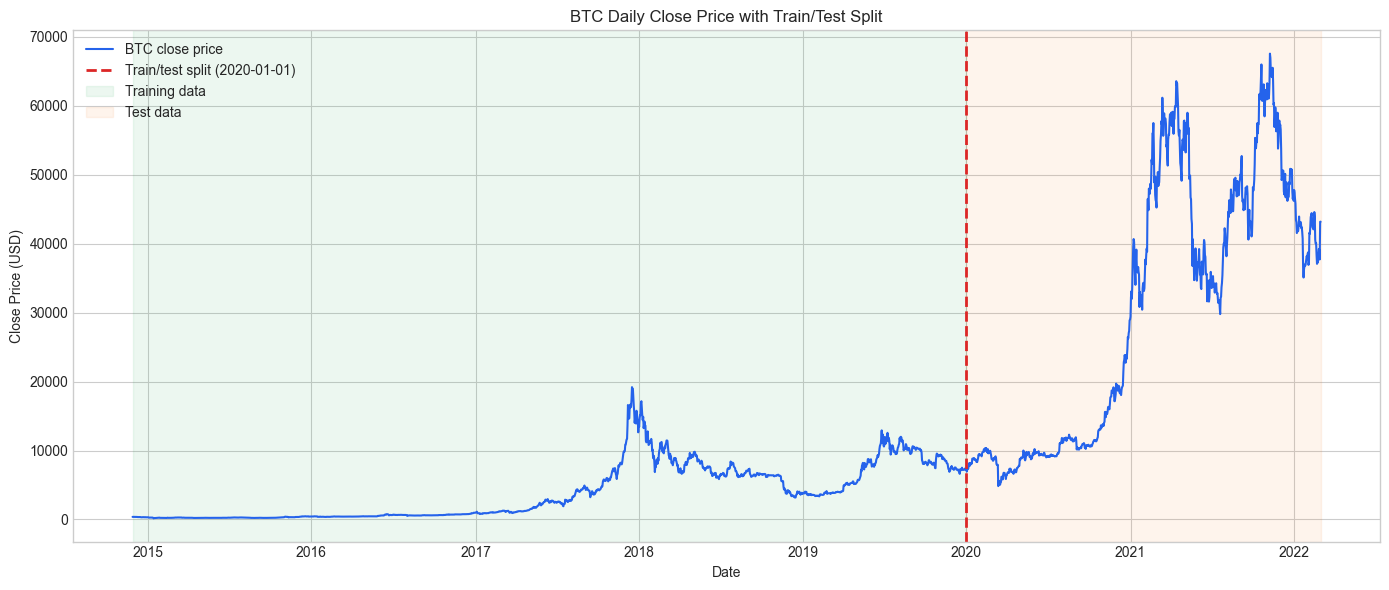

In [5]:
# Price trend visualisation: mark the train/test split point
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(price_data.index, price_data["close"], label="BTC close price", color="#2563eb", linewidth=1.5)
ax.axvline(SPLIT_DATE, color="#dc2626", linestyle="--", linewidth=2, label="Train/test split (2020-01-01)")

ax.axvspan(price_data.index.min(), SPLIT_DATE, color="#16a34a", alpha=0.08, label="Training data")
ax.axvspan(SPLIT_DATE, price_data.index.max(), color="#f97316", alpha=0.08, label="Test data")

ax.set_title("BTC Daily Close Price with Train/Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## 2. Bot Building Blocks (WMA Filters)

This section implements the core building blocks of the Trading Bot: padding, the Weighted Moving Average (WMA) convolution framework, the SMA/LMA/EMA filters, and crossover-based buy/sell signal detection.

### 2.1 Padding and WMA Framework

In [6]:
def pad(P, N):
    """Pad a price series by flipping the first N-1 interior values."""
    P = np.asarray(P, dtype=float)
    if N < 1:
        raise ValueError("N must be at least 1")
    if len(P) <= N:
        raise ValueError("Price series must contain more values than N")

    padding = -np.flip(P[1:N])
    return np.append(padding, P)


def wma(P, N, kernel):
    """Compute a weighted moving average by convolving a padded price series."""
    P = np.asarray(P, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    if len(kernel) != N:
        raise ValueError("Kernel length must match N")
    return np.convolve(pad(P, N), kernel, mode="valid")

### 2.2 SMA, LMA, and EMA Filters

The three filters correspond to the Simple Moving Average (SMA), Linear-Weighted Moving Average (LMA), and Exponential Moving Average (EMA). The EMA is implemented as a finite-window truncated version.

In [7]:
def sma_filter(N):
    """Return a Simple Moving Average filter."""
    if N < 1:
        raise ValueError("N must be at least 1")
    return np.ones(N, dtype=float) / N


def lma_filter(N):
    """Return a Linear-Weighted Moving Average filter."""
    if N < 1:
        raise ValueError("N must be at least 1")
    k = np.arange(N, dtype=float)
    weights = 1 - k * (1.0 / N)
    return weights * (2.0 / (N + 1))


def ema_filter(N, alpha):
    """Return a finite-window Exponential Moving Average filter."""
    if N < 1:
        raise ValueError("N must be at least 1")
    if not 0 < alpha < 1:
        raise ValueError("alpha must be between 0 and 1")
    k = np.arange(N, dtype=float)
    weights = (1 - alpha) ** k
    return weights * alpha

In [8]:
# Validate filter shapes, sums, monotonicity, and WMA output length
validation_prices = train_data[:120]
validation_window = 20
validation_alpha = 0.30

sma_kernel = sma_filter(validation_window)
lma_kernel = lma_filter(validation_window)
ema_kernel = ema_filter(validation_window, validation_alpha)

assert len(sma_kernel) == validation_window
assert len(lma_kernel) == validation_window
assert len(ema_kernel) == validation_window
assert np.isclose(sma_kernel.sum(), 1.0)
assert np.isclose(lma_kernel.sum(), 1.0)
assert np.all(np.diff(lma_kernel) < 0)
assert np.all(np.diff(ema_kernel) < 0)

for kernel in [sma_kernel, lma_kernel, ema_kernel]:
    filtered = wma(validation_prices, validation_window, kernel)
    assert len(filtered) == len(validation_prices)

print("Filter validation passed.")
print(f"SMA filter sum: {sma_kernel.sum():.6f}")
print(f"LMA filter sum: {lma_kernel.sum():.6f}")
print(f"EMA finite-window sum: {ema_kernel.sum():.6f}")
print(f"WMA output length: {len(filtered)} values")

Filter validation passed.
SMA filter sum: 1.000000
LMA filter sum: 1.000000
EMA finite-window sum: 0.999202
WMA output length: 120 values


This cell checks the basic properties of the SMA, LMA, and EMA filters, including weight sums, filter lengths, and output lengths.

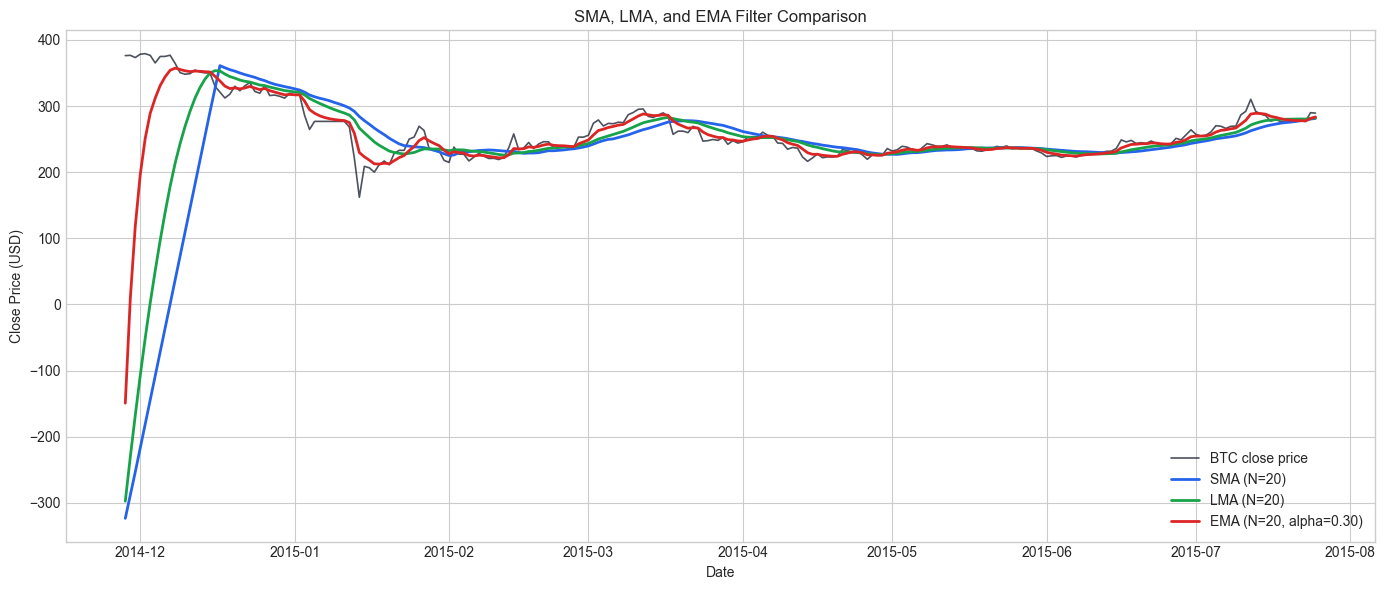

In [9]:
# Visual comparison of SMA, LMA, and EMA on the training price series
plot_points = 240
plot_prices = train_data[:plot_points]
plot_dates = train_prices.index[:plot_points]
window = 20
alpha = 0.30

sma_signal = wma(plot_prices, window, sma_filter(window))
lma_signal = wma(plot_prices, window, lma_filter(window))
ema_signal = wma(plot_prices, window, ema_filter(window, alpha))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(plot_dates, plot_prices, label="BTC close price", color="#111827", linewidth=1.2, alpha=0.75)
ax.plot(plot_dates, sma_signal, label="SMA (N=20)", color="#2563eb", linewidth=2)
ax.plot(plot_dates, lma_signal, label="LMA (N=20)", color="#16a34a", linewidth=2)
ax.plot(plot_dates, ema_signal, label="EMA (N=20, alpha=0.30)", color="#dc2626", linewidth=2)

ax.set_title("SMA, LMA, and EMA Filter Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

This figure compares the three WMA filters on the same segment of training prices. SMA is smoother, EMA responds faster, and LMA sits between the two.

### 2.3 Crossover Signal Detection

A short-term signal crossing above a long-term signal corresponds to a buy signal, while crossing below it corresponds to a sell signal. This section first implements a generic crossover detection function, which is later connected to the 14-dimensional Bot and the backtesting engine.

In [10]:
def sign_change_filter():
    """Return a simple sign-change filter from the project specification."""
    return np.array([0.5, -0.5], dtype=float)


def detect_buy_sell_signals(diff_signal):
    """Detect buy and sell indices from the difference between two signals.

    A buy signal occurs when the difference changes from negative to positive.
    A sell signal occurs when the difference changes from positive to negative.
    """
    diff_signal = np.asarray(diff_signal, dtype=float)
    sign_signal = np.sign(diff_signal)
    changes = np.diff(sign_signal)
    buy_indices = np.where(changes > 0)[0] + 1
    sell_indices = np.where(changes < 0)[0] + 1
    return buy_indices, sell_indices

In [11]:
# Validate crossover detection with a simple SMA(10) vs SMA(40) example
example_points = 720
example_prices = train_data[:example_points]
example_dates = train_prices.index[:example_points]

short_window = 10
long_window = 40
short_signal = wma(example_prices, short_window, sma_filter(short_window))
long_signal = wma(example_prices, long_window, sma_filter(long_window))
diff_signal = short_signal - long_signal
buy_indices, sell_indices = detect_buy_sell_signals(diff_signal)

assert len(short_signal) == len(example_prices)
assert len(long_signal) == len(example_prices)
assert len(buy_indices) > 0
assert len(sell_indices) > 0

print("Crossover validation passed.")
print(f"Buy signals detected: {len(buy_indices)}")
print(f"Sell signals detected: {len(sell_indices)}")
print(f"First five buy indices: {buy_indices[:5].tolist()}")
print(f"First five sell indices: {sell_indices[:5].tolist()}")

Crossover validation passed.
Buy signals detected: 8
Sell signals detected: 8
First five buy indices: [82, 162, 201, 303, 447]
First five sell indices: [38, 118, 185, 254, 414]


This cell uses SMA(10) and SMA(40) as a simple example to check whether the crossover detection logic can identify reasonable buy/sell signals.

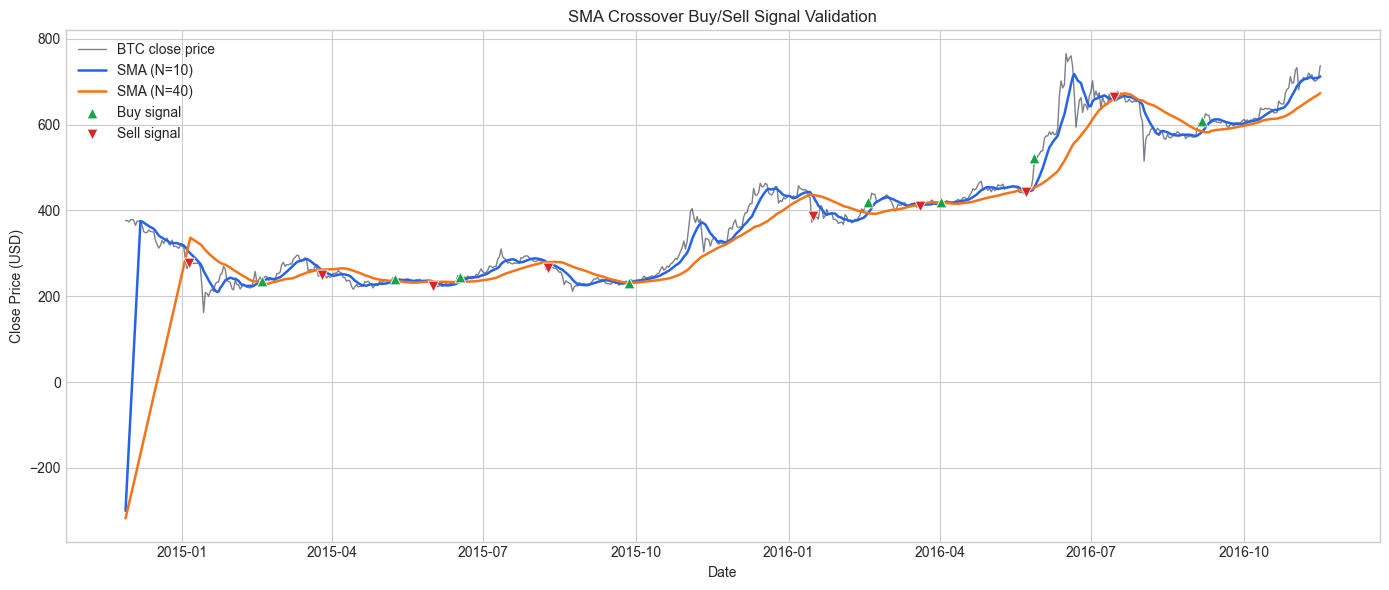

In [12]:
# Visual validation of crossover buy/sell signals
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(example_dates, example_prices, label="BTC close price", color="#111827", linewidth=1.0, alpha=0.55)
ax.plot(example_dates, short_signal, label="SMA (N=10)", color="#2563eb", linewidth=1.8)
ax.plot(example_dates, long_signal, label="SMA (N=40)", color="#f97316", linewidth=1.8)

ax.scatter(example_dates[buy_indices], example_prices[buy_indices], marker="^", s=60,
           color="#16a34a", edgecolor="white", linewidth=0.6, label="Buy signal", zorder=5)
ax.scatter(example_dates[sell_indices], example_prices[sell_indices], marker="v", s=60,
           color="#dc2626", edgecolor="white", linewidth=0.6, label="Sell signal", zorder=5)

ax.set_title("SMA Crossover Buy/Sell Signal Validation")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

After plotting the crossover signals on the price curve, the buy and sell points can be visually checked against the expected locations.

## 3. Bot Architecture & Parameterisation

This section implements two Trading Bot structures. The first is the 14-dimensional compound-signal Bot used in the main experiment, where both HIGH and LOW are weighted combinations of SMA, LMA, and EMA. The second is a 2-dimensional simple Bot that uses only a short-term SMA and a long-term SMA crossover, which is later used to compare the search difficulty of low-dimensional and high-dimensional parameter spaces.

### 3.1 14-Dimensional Compound Bot

The parameter vector `x` is ordered as `[w1, w2, w3, d1, d2, d3, alpha1, w4, w5, w6, d4, d5, d6, alpha2]`. The weights `w` control each filter's contribution, `d` is the duration/window size, and `alpha` is the EMA decay parameter.

In [13]:
PARAM_BOUNDS = [
    (0.0, 1.0),   # w1: SMA weight for HIGH
    (0.0, 1.0),   # w2: LMA weight for HIGH
    (0.0, 1.0),   # w3: EMA weight for HIGH
    (2, 50),      # d1: SMA window for HIGH
    (2, 50),      # d2: LMA window for HIGH
    (2, 50),      # d3: EMA window for HIGH
    (0.01, 0.99), # alpha1: EMA decay for HIGH
    (0.0, 1.0),   # w4: SMA weight for LOW
    (0.0, 1.0),   # w5: LMA weight for LOW
    (0.0, 1.0),   # w6: EMA weight for LOW
    (2, 100),     # d4: SMA window for LOW
    (2, 100),     # d5: LMA window for LOW
    (2, 100),     # d6: EMA window for LOW
    (0.01, 0.99), # alpha2: EMA decay for LOW
]

DIM = 14
DURATION_INDICES = [3, 4, 5, 10, 11, 12]
BOUNDS_LOW = np.array([lo for lo, _ in PARAM_BOUNDS], dtype=float)
BOUNDS_HIGH = np.array([hi for _, hi in PARAM_BOUNDS], dtype=float)


def clip_solution(x):
    """Clip a 14-dimensional solution to the legal parameter bounds."""
    x_clipped = np.asarray(x, dtype=float).copy()
    x_clipped = np.clip(x_clipped, BOUNDS_LOW, BOUNDS_HIGH)
    for idx in DURATION_INDICES:
        x_clipped[idx] = int(round(x_clipped[idx]))
    return x_clipped


def random_solution():
    """Generate a random 14-dimensional solution inside the parameter bounds."""
    x = np.array([np.random.uniform(lo, hi) for lo, hi in PARAM_BOUNDS], dtype=float)
    return clip_solution(x)

In [14]:
def build_signals(P, x):
    """Build HIGH and LOW signals from a 14-dimensional bot parameter vector."""
    P = np.asarray(P, dtype=float)
    x = clip_solution(x)

    w1, w2, w3 = x[0], x[1], x[2]
    d1, d2, d3 = int(x[3]), int(x[4]), int(x[5])
    alpha1 = x[6]
    w4, w5, w6 = x[7], x[8], x[9]
    d4, d5, d6 = int(x[10]), int(x[11]), int(x[12])
    alpha2 = x[13]

    sma_high = wma(P, d1, sma_filter(d1))
    lma_high = wma(P, d2, lma_filter(d2))
    ema_high = wma(P, d3, ema_filter(d3, alpha1))

    high_weight_sum = w1 + w2 + w3
    if high_weight_sum < 1e-10:
        high_weight_sum = 1.0
    high_signal = (w1 * sma_high + w2 * lma_high + w3 * ema_high) / high_weight_sum

    sma_low = wma(P, d4, sma_filter(d4))
    lma_low = wma(P, d5, lma_filter(d5))
    ema_low = wma(P, d6, ema_filter(d6, alpha2))

    low_weight_sum = w4 + w5 + w6
    if low_weight_sum < 1e-10:
        low_weight_sum = 1.0
    low_signal = (w4 * sma_low + w5 * lma_low + w6 * ema_low) / low_weight_sum

    return high_signal, low_signal

In [15]:
# Validate 14-dimensional signal construction
example_14d_solution = np.array([
    1.0, 0.0, 0.0, 10, 20, 20, 0.30,
    1.0, 0.0, 0.0, 40, 40, 40, 0.30,
])
example_high, example_low = build_signals(train_data, example_14d_solution)

assert len(example_high) == len(train_data)
assert len(example_low) == len(train_data)
assert np.all(np.isfinite(example_high))
assert np.all(np.isfinite(example_low))

print("14D bot signal validation passed.")
print(f"HIGH signal length: {len(example_high)}")
print(f"LOW signal length: {len(example_low)}")

14D bot signal validation passed.
HIGH signal length: 1860
LOW signal length: 1860


This cell runs a trial 14-dimensional parameter vector to confirm that the HIGH and LOW signals can be generated from the full parameter vector.

### 3.2 2-Dimensional Simple SMA Bot

The simple Bot contains only two parameters: the short-term SMA window `N1` and the long-term SMA window `N2`. It serves as the low-dimensional control group for analysing whether the larger hypothesis space of the high-dimensional Bot is worth the additional search cost.

In [16]:
SIMPLE_PARAM_BOUNDS = [
    (2, 50),    # N1: short-term SMA window
    (10, 200),  # N2: long-term SMA window
]

SIMPLE_DIM = 2
SIMPLE_BOUNDS_LOW = np.array([lo for lo, _ in SIMPLE_PARAM_BOUNDS], dtype=float)
SIMPLE_BOUNDS_HIGH = np.array([hi for _, hi in SIMPLE_PARAM_BOUNDS], dtype=float)


def clip_simple_solution(x):
    """Clip a 2-dimensional simple-bot solution to legal bounds."""
    x_clipped = np.asarray(x, dtype=float).copy()
    x_clipped = np.clip(x_clipped, SIMPLE_BOUNDS_LOW, SIMPLE_BOUNDS_HIGH)
    return np.array([int(round(x_clipped[0])), int(round(x_clipped[1]))], dtype=float)


def random_simple_solution():
    """Generate a random 2-dimensional simple-bot solution."""
    x = np.array([np.random.uniform(lo, hi) for lo, hi in SIMPLE_PARAM_BOUNDS], dtype=float)
    return clip_simple_solution(x)


def build_simple_signals(P, x):
    """Build short-term and long-term SMA signals for the simple bot."""
    P = np.asarray(P, dtype=float)
    x = clip_simple_solution(x)
    n1, n2 = int(x[0]), int(x[1])
    high_signal = wma(P, n1, sma_filter(n1))
    low_signal = wma(P, n2, sma_filter(n2))
    return high_signal, low_signal

In [17]:
# Validate 2-dimensional simple bot signal construction
simple_example_solution = np.array([10, 40])
simple_high, simple_low = build_simple_signals(train_data, simple_example_solution)

assert len(simple_high) == len(train_data)
assert len(simple_low) == len(train_data)
assert np.all(np.isfinite(simple_high))
assert np.all(np.isfinite(simple_low))

print("Simple bot signal validation passed.")
print(f"Short SMA length: {len(simple_high)}")
print(f"Long SMA length: {len(simple_low)}")

Simple bot signal validation passed.
Short SMA length: 1860
Long SMA length: 1860


This cell checks whether the short-term and long-term signals of the 2-dimensional Simple SMA Bot can be generated correctly. It is later used as the low-dimensional control group for comparing the simple search space with the 14-dimensional compound space.

## 4. Fitness Evaluation Function

This section implements the Fitness Function and the Backtesting Engine.

In [18]:
INITIAL_CASH = 1000.0
FEE_RATE = 0.03


def backtest_signals(P, high_signal, low_signal, return_trades=False):
    """Backtest a crossover strategy and return final cash fitness."""
    P = np.asarray(P, dtype=float)
    high_signal = np.asarray(high_signal, dtype=float)
    low_signal = np.asarray(low_signal, dtype=float)

    if len(P) != len(high_signal) or len(P) != len(low_signal):
        raise ValueError("Price and signal arrays must have the same length")
    if len(P) == 0:
        raise ValueError("Price series must not be empty")

    diff = high_signal - low_signal
    buy_indices, sell_indices = detect_buy_sell_signals(diff)

    trades = []
    for idx in buy_indices:
        if idx < len(P):
            trades.append((int(idx), "buy"))
    for idx in sell_indices:
        if idx < len(P):
            trades.append((int(idx), "sell"))
    trades.sort(key=lambda item: item[0])

    cash = INITIAL_CASH
    btc = 0.0
    holding_btc = False
    executed_trades = []

    for idx, action in trades:
        price = P[idx]
        if action == "buy" and not holding_btc:
            btc = cash * (1 - FEE_RATE) / price
            cash = 0.0
            holding_btc = True
            executed_trades.append({"index": idx, "action": action, "price": price, "cash": cash, "btc": btc})
        elif action == "sell" and holding_btc:
            cash = btc * price * (1 - FEE_RATE)
            btc = 0.0
            holding_btc = False
            executed_trades.append({"index": idx, "action": action, "price": price, "cash": cash, "btc": btc})

    if holding_btc:
        final_idx = len(P) - 1
        cash = btc * P[final_idx] * (1 - FEE_RATE)
        btc = 0.0
        holding_btc = False
        executed_trades.append({"index": final_idx, "action": "final_sell", "price": P[final_idx], "cash": cash, "btc": btc})

    if return_trades:
        return cash, executed_trades
    return cash


def evaluate_bot(P, x, return_trades=False):
    """Evaluate the 14-dimensional compound bot on a price series."""
    try:
        high_signal, low_signal = build_signals(P, x)
        return backtest_signals(P, high_signal, low_signal, return_trades=return_trades)
    except Exception:
        if return_trades:
            return INITIAL_CASH, []
        return INITIAL_CASH


def evaluate_simple_bot(P, x, return_trades=False):
    """Evaluate the 2-dimensional simple SMA crossover bot on a price series."""
    try:
        high_signal, low_signal = build_simple_signals(P, x)
        return backtest_signals(P, high_signal, low_signal, return_trades=return_trades)
    except Exception:
        if return_trades:
            return INITIAL_CASH, []
        return INITIAL_CASH

In [19]:
# Fitness sanity check using known SMA(10) vs SMA(40) parameters
sma_10_40_14d = np.array([
    1.0, 0.0, 0.0, 10, 20, 20, 0.30,
    1.0, 0.0, 0.0, 40, 40, 40, 0.30,
])
sma_10_40_simple = np.array([10, 40])

train_fitness_14d, train_trades_14d = evaluate_bot(train_data, sma_10_40_14d, return_trades=True)
test_fitness_14d, test_trades_14d = evaluate_bot(test_data, sma_10_40_14d, return_trades=True)
train_fitness_simple, train_trades_simple = evaluate_simple_bot(train_data, sma_10_40_simple, return_trades=True)
test_fitness_simple, test_trades_simple = evaluate_simple_bot(test_data, sma_10_40_simple, return_trades=True)

assert np.isclose(train_fitness_14d, train_fitness_simple)
assert np.isclose(test_fitness_14d, test_fitness_simple)
assert train_fitness_14d > 0
assert test_fitness_14d > 0

print("Fitness validation passed.")
print(f"14D SMA(10,40) train fitness: ${train_fitness_14d:.2f}")
print(f"14D SMA(10,40) test fitness: ${test_fitness_14d:.2f}")
print(f"Simple SMA(10,40) train fitness: ${train_fitness_simple:.2f}")
print(f"Simple SMA(10,40) test fitness: ${test_fitness_simple:.2f}")
print(f"Train executed trades: {len(train_trades_14d)}")
print(f"Test executed trades: {len(test_trades_14d)}")

Fitness validation passed.
14D SMA(10,40) train fitness: $10576.12
14D SMA(10,40) test fitness: $3938.82
Simple SMA(10,40) train fitness: $10576.12
Simple SMA(10,40) test fitness: $3938.82
Train executed trades: 46
Test executed trades: 16


This step checks the fitness evaluation using a known set of SMA parameters. The trade count, final cash, and fitness are all returned correctly, confirming that the fee, all-in trading, and final liquidation rules are connected.

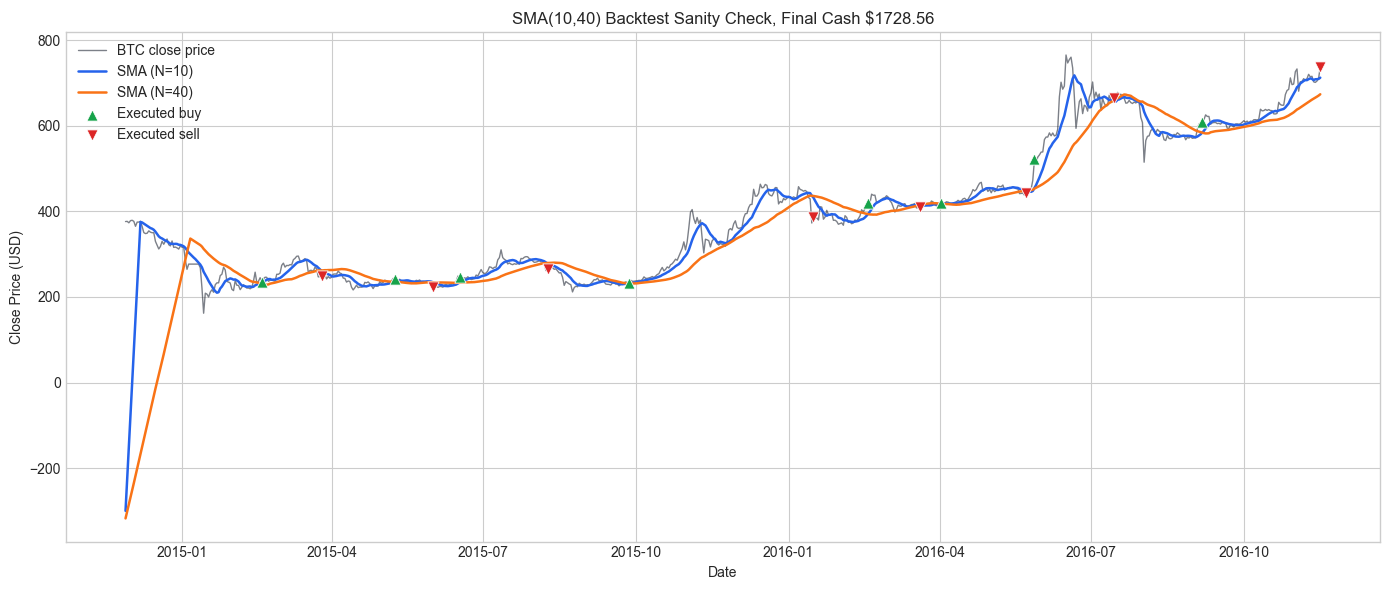

In [20]:
# Visual sanity check for the SMA(10,40) backtest on training data
visual_points = 720
visual_prices = train_data[:visual_points]
visual_dates = train_prices.index[:visual_points]
visual_high, visual_low = build_simple_signals(visual_prices, sma_10_40_simple)
visual_fitness, visual_trades = evaluate_simple_bot(visual_prices, sma_10_40_simple, return_trades=True)

buy_trade_indices = [trade["index"] for trade in visual_trades if trade["action"] == "buy"]
sell_trade_indices = [trade["index"] for trade in visual_trades if trade["action"] in ["sell", "final_sell"]]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(visual_dates, visual_prices, label="BTC close price", color="#111827", linewidth=1.0, alpha=0.55)
ax.plot(visual_dates, visual_high, label="SMA (N=10)", color="#2563eb", linewidth=1.8)
ax.plot(visual_dates, visual_low, label="SMA (N=40)", color="#f97316", linewidth=1.8)

if buy_trade_indices:
    ax.scatter(visual_dates[buy_trade_indices], visual_prices[buy_trade_indices], marker="^", s=65,
               color="#16a34a", edgecolor="white", linewidth=0.6, label="Executed buy", zorder=5)
if sell_trade_indices:
    ax.scatter(visual_dates[sell_trade_indices], visual_prices[sell_trade_indices], marker="v", s=65,
               color="#dc2626", edgecolor="white", linewidth=0.6, label="Executed sell", zorder=5)

ax.set_title(f"SMA(10,40) Backtest Sanity Check, Final Cash ${visual_fitness:.2f}")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

This figure shows the example strategy's buy/sell points together with its equity curve. It helps confirm that trade execution and capital changes in the backtest match the stated rules.

## 5. Optimisation Helper Functions

This section keeps the shared population evaluation helper used by all optimisation algorithms.

In [21]:
def evaluate_population(P, population, evaluator=evaluate_bot):
    """Evaluate every individual in a population."""
    return np.array([evaluator(P, individual) for individual in population], dtype=float)

## 6. Algorithm 1: Whale Optimisation Algorithm (WOA)

This section implements the Whale Optimisation Algorithm (WOA) proposed by Mirjalili and Lewis from scratch. The algorithm switches between encircling prey, searching for prey, and spiral updating, using the current global best solution to guide the search.

In [22]:
def whale_optimisation_algorithm(P, n_whales=50, max_iter=100, verbose=True):
    """Optimise the 14-dimensional bot with the Whale Optimisation Algorithm."""
    if n_whales < 2:
        raise ValueError("n_whales must be at least 2")
    if max_iter < 1:
        raise ValueError("max_iter must be at least 1")

    # Each whale is a 14-dimensional Bot parameter vector, initialised randomly within the valid bounds.
    whales = np.array([random_solution() for _ in range(n_whales)], dtype=float)
    fitness_values = evaluate_population(P, whales)
    eval_count = n_whales

    # WOA uses the current global-best whale X* as the prey position, and all updates are built around it.
    best_index = int(np.argmax(fitness_values))
    best_solution = whales[best_index].copy()
    best_fitness = float(fitness_values[best_index])
    fitness_history = [best_fitness]
    eval_count_history = [eval_count]

    # b controls the shape of the spiral update and is usually set to 1 in standard WOA.
    b = 1.0
    if verbose:
        print(f"WOA initial best fitness: ${best_fitness:.2f}")

    for iteration in range(max_iter):
        # a decreases linearly from 2 to 0: early iterations make |A| more likely to exceed 1 for exploration, while later iterations favour encircling the best solution.
        a = 2.0 - 2.0 * (iteration / max_iter)
        updated_whales = whales.copy()

        for i in range(n_whales):
            # p decides whether this update uses shrinking encircling/random search or the spiral attacking mechanism.
            p = np.random.random()

            if p < 0.5:
                # r is a dimension-wise random vector, giving each parameter dimension a different search step size.
                r = np.random.random(DIM)
                # A controls movement direction and strength; C randomly scales the target position to increase perturbation.
                A = 2.0 * a * r - a
                C = 2.0 * r

                if np.max(np.abs(A)) < 1.0:
                    # When |A|<1, perform encircling prey: shrink the search around the current best X*.
                    distance = np.abs(C * best_solution - whales[i])
                    updated_whales[i] = best_solution - A * distance
                else:
                    # When |A|>=1, perform search for prey: follow a random whale to reduce premature convergence around a local optimum.
                    random_index = np.random.randint(n_whales)
                    random_whale = whales[random_index]
                    distance = np.abs(C * random_whale - whales[i])
                    updated_whales[i] = random_whale - A * distance
            else:
                # l controls the spiral phase; positive and negative values move the whale around X* along a logarithmic spiral.
                l = np.random.uniform(-1.0, 1.0)
                distance_to_best = np.abs(best_solution - whales[i])
                # Spiral updating: D*exp(b*l)*cos(2*pi*l)+X*, modelling bubble-net spiral feeding.
                updated_whales[i] = distance_to_best * np.exp(b * l) * np.cos(2 * np.pi * l) + best_solution

            # Clip after every position update to keep alpha, weights, and window lengths within bounds.
            updated_whales[i] = clip_solution(updated_whales[i])

        whales = updated_whales
        # Each whale produces one new candidate solution per iteration, so the evaluation count increases by n_whales.
        fitness_values = evaluate_population(P, whales)
        eval_count += n_whales

        iteration_best_index = int(np.argmax(fitness_values))
        iteration_best_fitness = float(fitness_values[iteration_best_index])
        # Update X* so all whales use the new best position as the prey reference in the next iteration.
        if iteration_best_fitness > best_fitness:
            best_fitness = iteration_best_fitness
            best_solution = whales[iteration_best_index].copy()

        fitness_history.append(best_fitness)
        eval_count_history.append(eval_count)

        if verbose:
            print(
                f"WOA iteration {iteration + 1:03d}/{max_iter}, "
                f"best fitness: ${best_fitness:.2f}, evaluations: {eval_count}"
            )

    return best_solution, best_fitness, fitness_history, eval_count_history

In [23]:
# Quick WOA smoke test required for this stage
np.random.seed(RANDOM_SEED)

woa_quick_solution, woa_quick_fitness, woa_quick_history, woa_quick_evals = whale_optimisation_algorithm(
    train_data,
    n_whales=10,
    max_iter=5,
    verbose=True,
)

assert len(woa_quick_solution) == DIM
assert len(woa_quick_history) == 6
assert len(woa_quick_evals) == 6
assert woa_quick_evals[-1] == 60
assert np.isfinite(woa_quick_fitness)
assert woa_quick_fitness > 0

print("WOA quick test passed.")
print(f"WOA quick best fitness: ${woa_quick_fitness:.2f}")
print(f"WOA quick evaluation count: {woa_quick_evals[-1]}")
print(f"WOA quick best solution: {np.round(woa_quick_solution, 4).tolist()}")

WOA initial best fitness: $10190.16
WOA iteration 001/5, best fitness: $17988.29, evaluations: 20
WOA iteration 002/5, best fitness: $19191.09, evaluations: 30
WOA iteration 003/5, best fitness: $19191.09, evaluations: 40
WOA iteration 004/5, best fitness: $21605.89, evaluations: 50
WOA iteration 005/5, best fitness: $21605.89, evaluations: 60
WOA quick test passed.
WOA quick best fitness: $21605.89
WOA quick evaluation count: 60
WOA quick best solution: [0.3459, 0.0, 0.0, 27.0, 2.0, 9.0, 0.01, 0.2871, 0.1901, 0.6318, 11.0, 78.0, 2.0, 0.2966]


The WOA quick test successfully returns the best solution, best fitness, and convergence record. This mainly verifies that the algorithm flow is connected to the evaluator, rather than serving as the final experimental conclusion.

## 7. Algorithm 2: Particle Swarm Optimisation (PSO) and Random Search

This section implements the original 1995 Particle Swarm Optimisation (PSO) by Kennedy and Eberhart from scratch, using `Vmax` to clip velocity dimension by dimension. It then implements the Random Search baseline as the random-search control.

In [24]:
def particle_swarm_optimisation(P, n_particles=50, max_iter=100,
                                 c1=2.0, c2=2.0, vmax_fraction=0.3,
                                 verbose=True):
    """Optimise the 14-dimensional bot with original PSO without inertia weight."""
    if n_particles < 2:
        raise ValueError("n_particles must be at least 2")
    if max_iter < 1:
        raise ValueError("max_iter must be at least 1")
    if vmax_fraction <= 0:
        raise ValueError("vmax_fraction must be positive")

    # Particle positions are Bot parameters; all positions are randomly initialised within the valid search space.
    positions = np.array([random_solution() for _ in range(n_particles)], dtype=float)
    # Vmax is a fixed fraction of each dimension's search range and is used for velocity clamping in original PSO.
    vmax = vmax_fraction * (BOUNDS_HIGH - BOUNDS_LOW)
    # Initial velocities can move in positive or negative directions, but their magnitudes are capped by Vmax to avoid jumping outside the bounds immediately.
    velocities = np.random.uniform(-vmax, vmax, size=(n_particles, DIM))

    fitness_values = evaluate_population(P, positions)
    eval_count = n_particles

    # pbest stores the best position each particle has visited so far.
    personal_best_positions = positions.copy()
    personal_best_fitness = fitness_values.copy()

    # gbest stores the best position found by the whole swarm so far and is the target of the social learning term.
    best_index = int(np.argmax(personal_best_fitness))
    global_best_position = personal_best_positions[best_index].copy()
    global_best_fitness = float(personal_best_fitness[best_index])
    fitness_history = [global_best_fitness]
    eval_count_history = [eval_count]

    if verbose:
        print(f"PSO initial best fitness: ${global_best_fitness:.2f}")

    for iteration in range(1, max_iter + 1):
        for i in range(n_particles):
            # r1 and r2 are dimension-wise random weights that add stochastic exploration to the cognitive and social terms.
            r1 = np.random.random(DIM)
            r2 = np.random.random(DIM)
            # The cognitive term pulls the particle back toward its own historical best position, pbest.
            cognitive = c1 * r1 * (personal_best_positions[i] - positions[i])
            # The social term pulls the particle toward the swarm's historical best position, gbest.
            social = c2 * r2 * (global_best_position - positions[i])
            # New velocity = old velocity + cognitive + social.
            velocities[i] = velocities[i] + cognitive + social
            # Prevent large jumps from destabilising the search.
            velocities[i] = np.clip(velocities[i], -vmax, vmax)
            # Move the position forward by its velocity; clip_solution handles both bounds and integer rounding for window lengths.
            positions[i] = clip_solution(positions[i] + velocities[i])

        fitness_values = evaluate_population(P, positions)
        eval_count += n_particles

        # Update pbest only when the current position improves on the personal historical best, preserving each particle's best experience.
        improved = fitness_values > personal_best_fitness
        personal_best_positions[improved] = positions[improved]
        personal_best_fitness[improved] = fitness_values[improved]

        # Select gbest from all pbest values rather than only current positions, preserving best-so-far monotonicity.
        best_index = int(np.argmax(personal_best_fitness))
        if personal_best_fitness[best_index] > global_best_fitness:
            global_best_fitness = float(personal_best_fitness[best_index])
            global_best_position = personal_best_positions[best_index].copy()

        fitness_history.append(global_best_fitness)
        eval_count_history.append(eval_count)

        if verbose:
            print(
                f"PSO iteration {iteration:03d}/{max_iter}, "
                f"best fitness: ${global_best_fitness:.2f}, evaluations: {eval_count}"
            )

    return global_best_position, global_best_fitness, fitness_history, eval_count_history

In [25]:
def random_search(P, max_evaluations=5000, verbose=True):
    """Uniform random search baseline over the 14-dimensional parameter space."""
    if max_evaluations < 1:
        raise ValueError("max_evaluations must be at least 1")

    best_solution = random_solution()
    best_fitness = float(evaluate_bot(P, best_solution))
    fitness_history = [best_fitness]
    eval_count_history = [1]

    if verbose:
        print(f"Random Search initial best fitness: ${best_fitness:.2f}")

    for evaluation in range(2, max_evaluations + 1):
        candidate = random_solution()
        candidate_fitness = float(evaluate_bot(P, candidate))
        if candidate_fitness > best_fitness:
            best_fitness = candidate_fitness
            best_solution = candidate.copy()

        fitness_history.append(best_fitness)
        eval_count_history.append(evaluation)

        if verbose and (evaluation == max_evaluations or evaluation % 10 == 0):
            print(
                f"Random Search evaluation {evaluation:04d}/{max_evaluations}, "
                f"best fitness: ${best_fitness:.2f}"
            )

    return best_solution, best_fitness, fitness_history, eval_count_history

In [26]:
# Quick PSO and Random Search smoke tests required for this stage
np.random.seed(RANDOM_SEED)

pso_quick_solution, pso_quick_fitness, pso_quick_history, pso_quick_evals = particle_swarm_optimisation(
    train_data,
    n_particles=10,
    max_iter=5,
    c1=2.0,
    c2=2.0,
    vmax_fraction=0.3,
    verbose=True,
)

np.random.seed(RANDOM_SEED)
random_quick_solution, random_quick_fitness, random_quick_history, random_quick_evals = random_search(
    train_data,
    max_evaluations=60,
    verbose=True,
)

assert len(pso_quick_solution) == DIM
assert len(pso_quick_history) == 6
assert len(pso_quick_evals) == 6
assert pso_quick_evals[-1] == 60
assert np.isfinite(pso_quick_fitness)
assert pso_quick_fitness > 0

assert len(random_quick_solution) == DIM
assert len(random_quick_history) == 60
assert len(random_quick_evals) == 60
assert random_quick_evals[-1] == 60
assert np.isfinite(random_quick_fitness)
assert random_quick_fitness > 0

print("PSO quick test passed.")
print(f"PSO quick best fitness: ${pso_quick_fitness:.2f}")
print(f"PSO quick evaluation count: {pso_quick_evals[-1]}")
print(f"PSO quick best solution: {np.round(pso_quick_solution, 4).tolist()}")
print("Random Search quick test passed.")
print(f"Random Search quick best fitness: ${random_quick_fitness:.2f}")
print(f"Random Search quick evaluation count: {random_quick_evals[-1]}")
print(f"Random Search quick best solution: {np.round(random_quick_solution, 4).tolist()}")

PSO initial best fitness: $10190.16
PSO iteration 001/5, best fitness: $10190.16, evaluations: 20


PSO iteration 002/5, best fitness: $18944.57, evaluations: 30
PSO iteration 003/5, best fitness: $18944.57, evaluations: 40
PSO iteration 004/5, best fitness: $18944.57, evaluations: 50
PSO iteration 005/5, best fitness: $18944.57, evaluations: 60
Random Search initial best fitness: $694.60
Random Search evaluation 0010/60, best fitness: $10190.16
Random Search evaluation 0020/60, best fitness: $12472.85
Random Search evaluation 0030/60, best fitness: $20437.28
Random Search evaluation 0040/60, best fitness: $20437.28
Random Search evaluation 0050/60, best fitness: $20437.28
Random Search evaluation 0060/60, best fitness: $20437.28
PSO quick test passed.
PSO quick best fitness: $18944.57
PSO quick evaluation count: 60
PSO quick best solution: [0.5868, 0.0, 0.4572, 25.0, 14.0, 20.0, 0.6718, 0.1134, 0.3391, 0.3676, 38.0, 100.0, 23.0, 0.5875]
Random Search quick test passed.
Random Search quick best fitness: $20437.28
Random Search quick evaluation count: 60
Random Search quick best solut